# Individual factor comparison

Quickly compare a single factor file (e.g., `out_factors/adm.csv`) against the same factor inside `data-replication/factors_copy.csv`. Update the parameters below to swap in other factor files.

In [73]:
from pathlib import Path
import numpy as np
import pandas as pd

FACTOR_FILE = Path("out_factors/std_turn.csv")
FACTOR_COL = "std_turn"
DATE_COL = "date"

REFERENCE_FILE = Path("../data-replication/factors_copy.csv")
REFERENCE_FACTOR_COL = FACTOR_COL
REFERENCE_DATE_COL = "Date"

In [74]:
# Load factor file
def _parse_date(series):
    s = series.copy()
    if s.dtype in ("int64", "float64"):
        s = s.astype("Int64").astype(str)
    s = s.astype(str).str.replace('-', '').str.strip()
    return pd.to_datetime(s, format="%Y%m%d", errors="coerce")

factor_df = pd.read_csv(FACTOR_FILE)
if DATE_COL not in factor_df.columns or FACTOR_COL not in factor_df.columns:
    raise ValueError(f"Factor file must contain {DATE_COL!r} and {FACTOR_COL!r} columns")

factor = factor_df[[DATE_COL, FACTOR_COL]].copy()
factor['date'] = _parse_date(factor[DATE_COL])
factor = factor.dropna(subset=['date', FACTOR_COL]).rename(columns={FACTOR_COL: 'value_new'})
factor['month'] = factor['date'].dt.to_period('M')
factor = factor.dropna(subset=['month']).drop_duplicates(subset=['month'], keep='last')

# Load reference file
ref_df = pd.read_csv(REFERENCE_FILE)
if REFERENCE_DATE_COL not in ref_df.columns or REFERENCE_FACTOR_COL not in ref_df.columns:
    raise ValueError(f"Reference file must contain {REFERENCE_DATE_COL!r} and {REFERENCE_FACTOR_COL!r} columns")

ref = ref_df[[REFERENCE_DATE_COL, REFERENCE_FACTOR_COL]].copy()
ref['date'] = _parse_date(ref[REFERENCE_DATE_COL])
ref = ref.dropna(subset=['date', REFERENCE_FACTOR_COL]).rename(columns={REFERENCE_FACTOR_COL: 'value_ref'})
ref['month'] = ref['date'].dt.to_period('M')
ref = ref.dropna(subset=['month']).drop_duplicates(subset=['month'], keep='last')

# Align on common months (avoids duplicate-date cartesian joins)
merged = (
    factor.merge(ref, on='month', how='inner', suffixes=('_new', '_ref'))
    .assign(date=lambda x: x['month'].dt.to_timestamp('M'))
    .sort_values('date')
    .reset_index(drop=True)
)
merged.head()


,date_new,value_new,month,Date,value_ref,date_ref,date
0,1976-07-30,-0.030402,1976-07,19760730,-0.022203,1976-07-30,1976-07-31
1,1976-08-31,-0.028651,1976-08,19760831,-0.023154,1976-08-31,1976-08-31
2,1976-09-30,0.004623,1976-09,19760930,0.006274,1976-09-30,1976-09-30
3,1976-10-29,-0.027112,1976-10,19761029,-0.020325,1976-10-29,1976-10-31
4,1976-11-30,0.028350,1976-11,19761130,0.027218,1976-11-30,1976-11-30


In [75]:
# Summary statistics
if merged.empty:
    raise ValueError("No overlapping dates between factor file and reference file.")

diff = merged["value_new"] - merged["value_ref"]
metrics = {
    "obs": len(merged),
    "corr": merged["value_new"].corr(merged["value_ref"]),
    "mae": diff.abs().mean(),
    "mse": (diff ** 2).mean(),
    "rmse": np.sqrt((diff ** 2).mean()),
    "mean_diff": diff.mean(),
    "median_diff": diff.median(),
}
pd.DataFrame.from_dict(metrics, orient="index", columns=[FACTOR_COL])

,std_turn
obs,498.000000
corr,0.937585
mae,0.010373
mse,0.000219
rmse,0.014812
mean_diff,-0.005008
median_diff,-0.003616


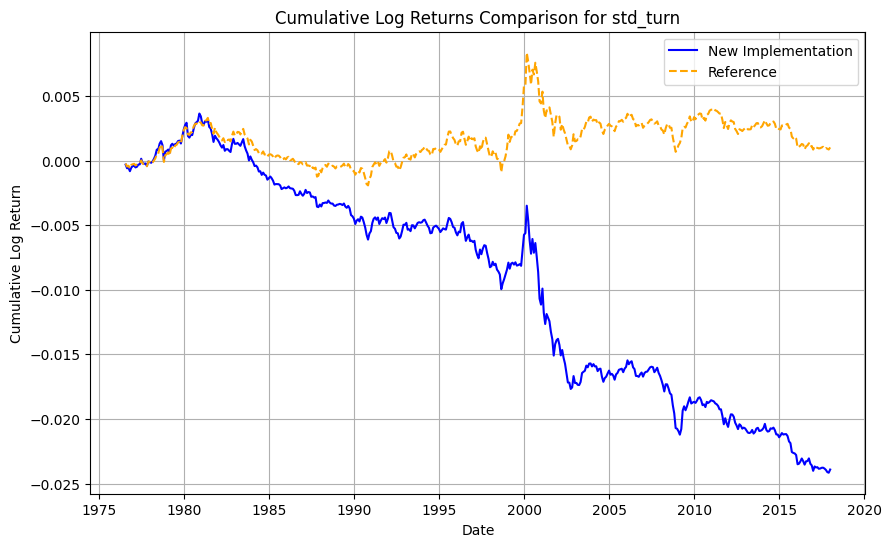

In [76]:
# Log cum returns comparison
import matplotlib.pyplot as plt
merged = merged.assign(
    logret_new=lambda x: np.log1p(x["value_new"] / 100),
    logret_ref=lambda x: np.log1p(x["value_ref"] / 100),
)
merged = merged.assign(
    cumlogret_new=lambda x: x["logret_new"].cumsum(),
    cumlogret_ref=lambda x: x["logret_ref"].cumsum(),
)
plt.figure(figsize=(10, 6))
plt.plot(merged["date"], merged["cumlogret_new"], label="New Implementation",
            color="blue")
plt.plot(merged["date"], merged["cumlogret_ref"], label="Reference",
            color="orange", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.title(f"Cumulative Log Returns Comparison for {FACTOR_COL}")
plt.legend()
plt.grid()
plt.show()

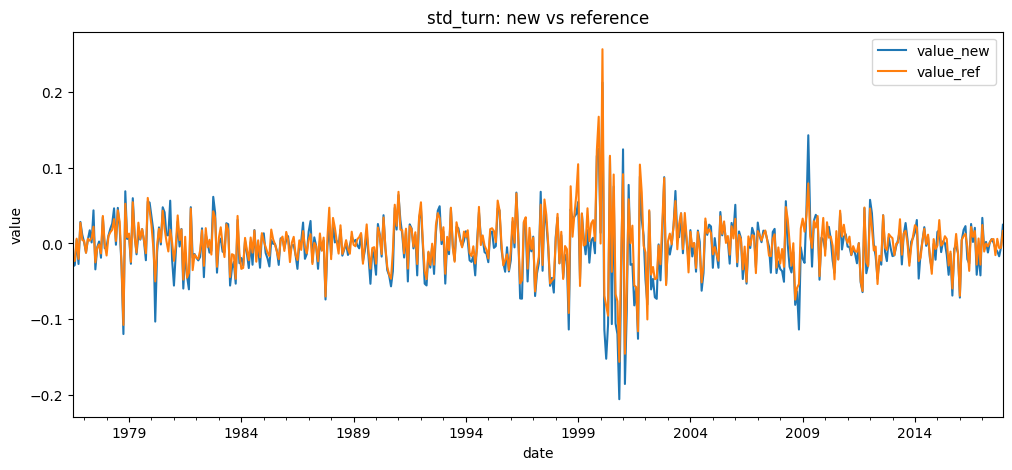

In [ ]:
# Time series overlay
ax = merged.plot(x="date", y=["value_new", "value_ref"], figsize=(12, 5), title=f"{FACTOR_COL}: new vs reference")
ax.set_ylabel("value")

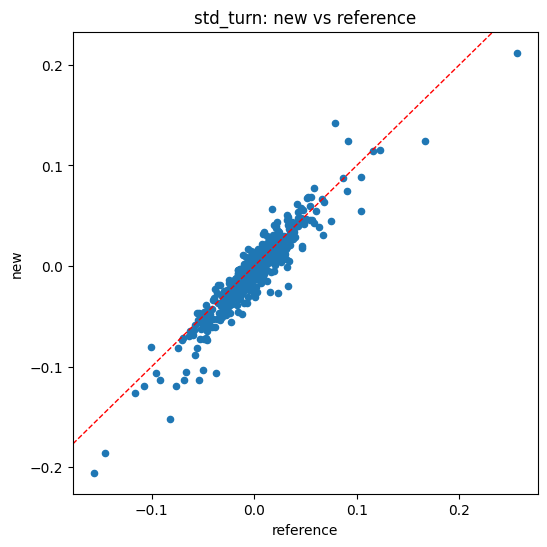

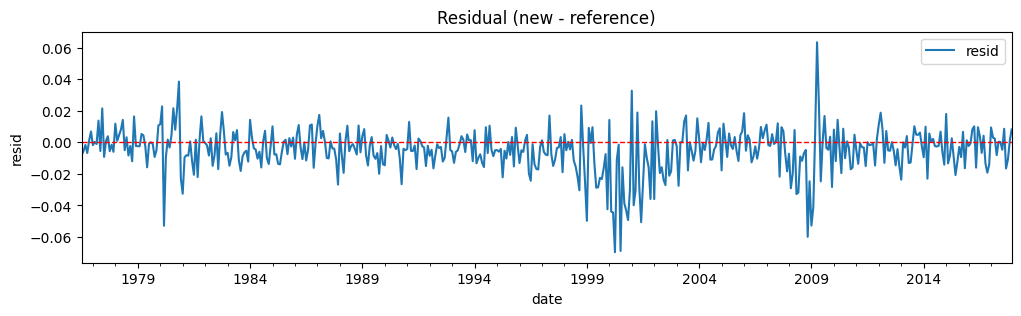

In [78]:
# Scatter and residual plot
ax = merged.plot.scatter(x="value_ref", y="value_new", figsize=(6, 6), title=f"{FACTOR_COL}: new vs reference")
ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("reference"); ax.set_ylabel("new");

ax_resid = merged.assign(resid=diff).plot(x="date", y="resid", figsize=(12, 3), title="Residual (new - reference)")
ax_resid.axhline(0, color="red", linestyle="--", linewidth=1)
ax_resid.set_ylabel("resid");